In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Dataset path

dataset_path = "./data/train"

print("Total images:", len(os.listdir(dataset_path)))

Total images: 25000


In [7]:
data = []
labels = []

image_size = 64

# Load cat images
for i in range(500):
    img_path = os.path.join(dataset_path, f"cat.{i}.jpg")

    img = cv2.imread(img_path)
    img = cv2.resize(img, (image_size, image_size))

    data.append(img.flatten())
    labels.append(0)

# Load dog images
for i in range(500):
    img_path = os.path.join(dataset_path, f"dog.{i}.jpg")

    img = cv2.imread(img_path)
    img = cv2.resize(img, (image_size, image_size))

    data.append(img.flatten())
    labels.append(1)

print("Images loaded successfully!")

Images loaded successfully!


In [8]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1000, 12288)
Labels shape: (1000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 12288)
Testing data: (200, 12288)


In [13]:
from sklearn.svm import SVC

# Create SVM model
model = SVC(kernel="rbf")

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
# Make predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 0 1 0 1 0 0 1 0]


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.61


In [16]:
# Normalize pixel values

data = data / 255.0

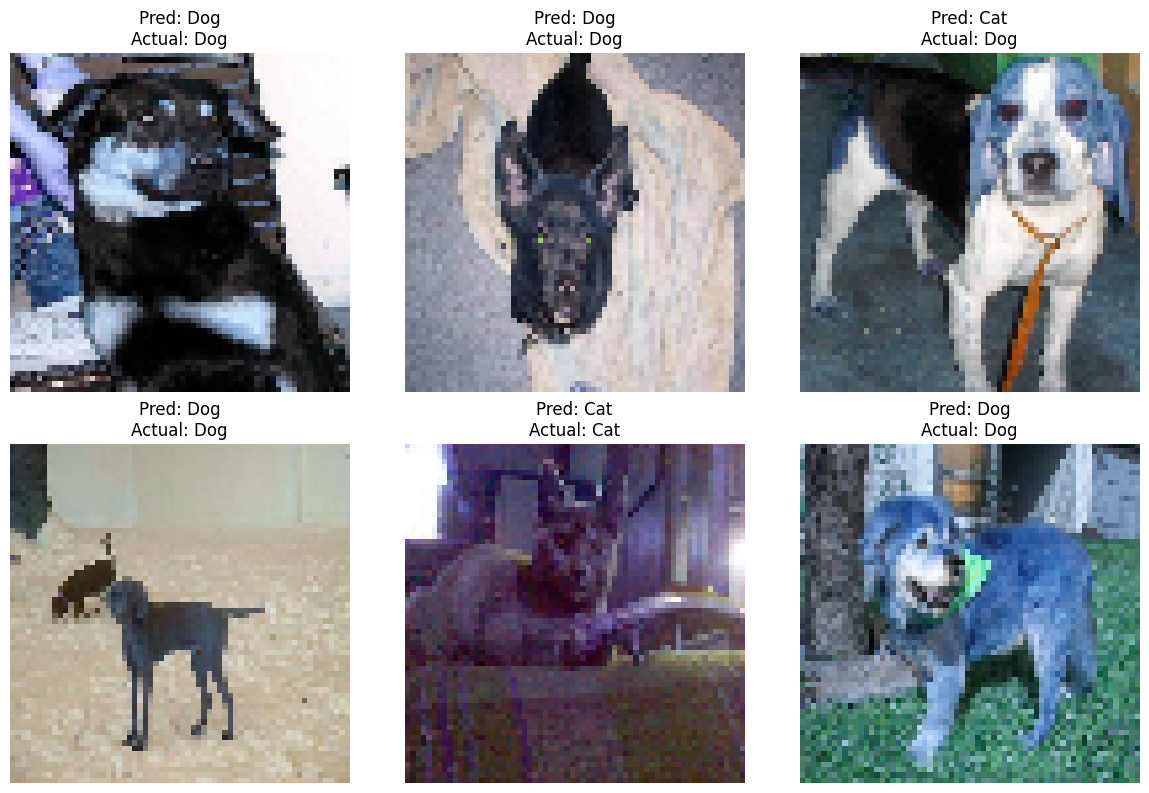

In [17]:
# Display some predictions

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_test[i].reshape(64,64,3)

    plt.imshow(img)

    prediction = "Dog" if y_pred[i] == 1 else "Cat"

    actual = "Dog" if y_test[i] == 1 else "Cat"

    plt.title(f"Pred: {prediction}\nActual: {actual}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import pickle

with open("models/cat_dog_svm.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
